1. Tạo base graph

In [1]:
import pandas as pd
from collections import Counter
import itertools
import gc

print("1. Nạp TẤT CẢ Metadata hữu ích...")
meta_cols = [
    'article_id', 'product_type_name', 'product_group_name', 'garment_group_name',
    'department_name', 'index_name', 'section_name', 'colour_group_name', 
    'fit', 'occasion', 'seasonality' # Cột sinh ra từ Qwen2-VL
]
df_meta = pd.read_csv("dataset_final_qwen_filled.csv", usecols=meta_cols, dtype={'article_id': str})
df_meta['article_id'] = df_meta['article_id'].str.zfill(10)

print("2. Quét giao dịch & Tạo Đồ thị thô (Base Graph)...")
df_trans = pd.read_csv("transactions_train.csv", usecols=["t_dat", "customer_id", "article_id"], dtype={"article_id": str})
df_trans["article_id"] = df_trans["article_id"].str.zfill(10)
df_trans = df_trans[df_trans["article_id"].isin(df_meta['article_id'])]
df_trans = df_trans.drop_duplicates(subset=['customer_id', 't_dat', 'article_id'])

baskets = df_trans.groupby(['customer_id', 't_dat'])['article_id'].apply(list).reset_index()
del df_trans
gc.collect()

baskets['size'] = baskets['article_id'].apply(len)
baskets = baskets[(baskets['size'] >= 2) & (baskets['size'] <= 10)]

pair_counter = Counter()
for items in baskets['article_id']:
    items = sorted(items)
    for pair in itertools.combinations(items, 2):
        pair_counter[pair] += 1

del baskets
gc.collect()

# Lọc sơ bộ: Chỉ giữ cặp mua chung >= 3 lần
base_pairs = [(k[0], k[1], v) for k, v in pair_counter.items() if v >= 3]
df_base_graph = pd.DataFrame(base_pairs, columns=['Item_A', 'Item_B', 'Count'])
print(f"-> Hoàn tất! Đồ thị thô có {len(df_base_graph):,} cặp.")

1. Nạp TẤT CẢ Metadata hữu ích...
2. Quét giao dịch & Tạo Đồ thị thô (Base Graph)...
-> Hoàn tất! Đồ thị thô có 2,138,128 cặp.


2. Chỉnh rule cho graph

**trước tiên kiểm tra unique đã**

In [251]:
import pandas as pd

# Giả định df_meta đã được load. Nếu báo lỗi chưa có df_meta, hãy bỏ dấu # ở dòng dưới:
# df_meta = pd.read_csv("dataset_final_qwen_filled.csv", dtype={'article_id': str})

print("=== TỔNG KHÁM NGHIỆM UNIQUE VALUES TẤT CẢ CÁC CỘT ===")

for col in df_meta.columns:
    # Bỏ qua các giá trị NaN để đếm chính xác
    unique_vals = df_meta[col].dropna().unique()
    num_uniques = len(unique_vals)
    
    print(f"\n--- CỘT: {col.upper()} ({num_uniques} unique values) ---")
    
    if num_uniques <= 350: 
        # Cột Categorical (Phân loại) -> In toàn bộ, sắp xếp A-Z cho dễ nhìn
        sorted_vals = sorted(list(unique_vals))
        print("['" + "', '".join(str(x) for x in sorted_vals) + "']")
    else:
        # Cột ID hoặc Text dài -> Chỉ in 5 ví dụ đại diện để không treo máy
        sample_vals = list(unique_vals)[:5]
        print(f"-> Quá nhiều giá trị. Dưới đây là 5 ví dụ đại diện:")
        print("['" + "', '".join(str(x) for x in sample_vals) + "', ...]")

=== TỔNG KHÁM NGHIỆM UNIQUE VALUES TẤT CẢ CÁC CỘT ===

--- CỘT: ARTICLE_ID (70197 unique values) ---
-> Quá nhiều giá trị. Dưới đây là 5 ví dụ đại diện:
['0108775015', '0108775044', '0108775051', '0110065001', '0110065002', ...]

--- CỘT: PRODUCT_TYPE_NAME (113 unique values) ---
['Alice band', 'Backpack', 'Bag', 'Ballerinas', 'Beanie', 'Belt', 'Bikini top', 'Blazer', 'Blouse', 'Bodysuit', 'Bootie', 'Boots', 'Bra', 'Bra extender', 'Bracelet', 'Braces', 'Bucket hat', 'Cap', 'Cap/peaked', 'Cardigan', 'Clothing mist', 'Coat', 'Costumes', 'Cross-body bag', 'Dog Wear', 'Dog wear', 'Dress', 'Dungarees', 'Earring', 'Earrings', 'Eyeglasses', 'Felt hat', 'Flat shoe', 'Flat shoes', 'Flip flop', 'Garment Set', 'Giftbox', 'Gloves', 'Hair clip', 'Hair string', 'Hair ties', 'Hair/alice band', 'Hairband', 'Hat/beanie', 'Hat/brim', 'Headband', 'Heeled sandals', 'Heels', 'Hoodie', 'Jacket', 'Jumpsuit/Playsuit', 'Keychain', 'Leggings/Tights', 'Long John', 'Marker pen', 'Mobile case', 'Necklace', 'Night 

In [ ]:
import pandas as pd

print("Đang nạp Luật phối đồ (Heuristics)...")
# Ghép Metadata cho Item A và Item B
df_test = df_base_graph.merge(df_meta.add_suffix('_A'), left_on='Item_A', right_on='article_id_A', how='left')
df_test = df_test.merge(df_meta.add_suffix('_B'), left_on='Item_B', right_on='article_id_B', how='left')

#rule 0
unwanted_groups = ['Under-, Nightwear'] 
hide_swimwear_for_testing = True # Đổi thành True nếu chỉ muốn test đồ mặc thường ngày

if hide_swimwear_for_testing:
    unwanted_groups.append('Swimwear')
    
rule_0 = (~df_test['garment_group_name_A'].isin(unwanted_groups)) & (~df_test['garment_group_name_B'].isin(unwanted_groups))


#rule 1: cung 1 tep khach hang
rule_1 = df_test['index_name_A'] == df_test['index_name_B']


#rule 2&3: Loại trừ phối đồ cùng loại chi tiết nhưng khác nhóm tổng quát 
# Cho phép Phụ kiện và Đồ bơi được mua chung cùng nhóm
allowed_same_groups = ['Accessories', 'Swimwear'] 

# Khác loại chi tiết (VD: Không phối 2 cái T-shirt)
rule_2 = (df_test['product_type_name_A'] != df_test['product_type_name_B']) | \
         (df_test['product_group_name_A'] == 'Accessories')

# Khác nhóm tổng quát ở cả 2 cấp độ (Chống lách luật metadata bị lỗi)
rule_3_prod = df_test['product_group_name_A'] != df_test['product_group_name_B']
rule_3_garm = df_test['garment_group_name_A'] != df_test['garment_group_name_B']
rule_3 = (rule_3_prod & rule_3_garm) | (df_test['product_group_name_A'].isin(allowed_same_groups))


# rule 5 loai tru cung nhom mau
rule_5 = df_test['Item_A'].str[:6] != df_test['Item_B'].str[:6] 


#rule 6 mau sac 
color_a = df_test['colour_group_name_A']
color_b = df_test['colour_group_name_B']

# Phân nhóm toàn bộ 50 màu của H&M
neutrals = ['Black', 'White', 'Off White', 'Grey', 'Light Grey', 'Dark Grey', 'Beige', 'Light Beige', 'Greyish Beige', 'Silver', 'Gold', 'Transparent']
navy_blues = ['Dark Blue', 'Navy'] # Theo bảng phối, Navy là màu trung tính thứ 2, phối được với mọi thứ
blues = ['Blue', 'Light Blue', 'Other Blue', 'Turquoise', 'Light Turquoise', 'Dark Turquoise']
greens = ['Green', 'Light Green', 'Dark Green', 'Greenish Khaki', 'Other Green', 'Olive']
pinks_reds = ['Red', 'Light Red', 'Dark Red', 'Pink', 'Light Pink', 'Dark Pink', 'Other Red', 'Other Pink', 'Burgundy']
yellows_oranges = ['Orange', 'Light Orange', 'Dark Orange', 'Yellow', 'Light Yellow', 'Dark Yellow', 'Other Yellow', 'Other Orange', 'Bronze/Copper']
browns = ['Brown', 'Dark Brown', 'Yellowish Brown']
purples = ['Purple', 'Light Purple', 'Dark Purple', 'Other Purple']

# 1. Các Trụ Cột An Toàn Tuyệt Đối (Chiếm phần lớn đồ thị)
rule_6_mono = color_a == color_b
rule_6_neutral = color_a.isin(neutrals) | color_b.isin(neutrals)
rule_6_navy = color_a.isin(navy_blues) | color_b.isin(navy_blues)

# Thẻ bài miễn tử: Quần Jeans xanh cân mọi Outfit
rule_6_denim = (df_test['garment_group_name_A'] == 'Trousers Denim') | (df_test['garment_group_name_B'] == 'Trousers Denim')

# 2. Phối cùng Tone (Tonal Matching)
rule_6_tonal_blue = color_a.isin(blues) & color_b.isin(blues)
rule_6_tonal_green = color_a.isin(greens) & color_b.isin(greens)
rule_6_tonal_redpink = color_a.isin(pinks_reds) & color_b.isin(pinks_reds)
rule_6_tonal_warm = color_a.isin(yellows_oranges) & color_b.isin(yellows_oranges)
rule_6_tonal_brown = color_a.isin(browns) & color_b.isin(browns)

rule_6_cross_earth = (color_a.isin(browns) & color_b.isin(greens + yellows_oranges)) | \
                     (color_b.isin(browns) & color_a.isin(greens + yellows_oranges))

rule_6_cross_blue_pink = (color_a.isin(blues) & color_b.isin(pinks_reds)) | \
                         (color_b.isin(blues) & color_a.isin(pinks_reds))

# Gộp Rule 6
rule_6 = (rule_6_mono | rule_6_neutral | rule_6_navy | rule_6_denim | 
          rule_6_tonal_blue | rule_6_tonal_green | rule_6_tonal_redpink | 
          rule_6_tonal_warm | rule_6_tonal_brown | rule_6_cross_earth | rule_6_cross_blue_pink)


#rule 7 xung dot mua theo mua
season_a = df_test['seasonality_A'].fillna('').str.lower()
season_b = df_test['seasonality_B'].fillna('').str.lower()

a_is_winter = season_a.str.contains('winter|fall|snow|cold|chill')
a_is_summer = season_a.str.contains('summer|beach|heat|hot')
b_is_winter = season_b.str.contains('winter|fall|snow|cold|chill')
b_is_summer = season_b.str.contains('summer|beach|heat|hot')
a_is_all_season = season_a.str.contains('all-season|all-year|any season|transition')
b_is_all_season = season_b.str.contains('all-season|all-year|any season|transition')

conflict_winter_summer = (a_is_winter & b_is_summer) & (~a_is_all_season) & (~b_is_all_season)
conflict_summer_winter = (a_is_summer & b_is_winter) & (~a_is_all_season) & (~b_is_all_season)

rule_7 = ~(conflict_winter_summer | conflict_summer_winter)


# rule 8 tranh section vibe xung dot
section_a = df_test['section_name_A'].fillna('')
section_b = df_test['section_name_B'].fillna('')

sports = ['Ladies H&M Sport', 'Men H&M Sport', 'Kids Sports']
formal = ['Womens Tailoring', 'Men Suits & Tailoring', 'Contemporary Smart']

a_is_sport, b_is_sport = section_a.isin(sports), section_b.isin(sports)
a_is_formal, b_is_formal = section_a.isin(formal), section_b.isin(formal)

rule_8 = ~((a_is_sport & b_is_formal) | (a_is_formal & b_is_sport))


final_mask = rule_0 & rule_1 & rule_2 & rule_3 & rule_5 & rule_6 & rule_7 & rule_8

df_filtered = df_test[final_mask].sort_values(by='Count', ascending=False).reset_index(drop=True)

print(f"\n=> HOÀN TẤT GỌT ĐỒ THỊ! SỐ CẶP OUTFIT SẠCH: {len(df_filtered):,}")

# Hiển thị text 10 cặp Top đầu để nhìn nhanh
cols_to_show = ['Count', 'product_type_name_A', 'product_type_name_B', 'garment_group_name_A', 'garment_group_name_B', 'colour_group_name_A', 'colour_group_name_B']
display(df_filtered[cols_to_show].head(10))

Đang nạp Luật phối đồ (Heuristics)...

=> HOÀN TẤT GỌT ĐỒ THỊ! SỐ CẶP OUTFIT SẠCH: 345,394


,Count,product_type_name_A,product_type_name_B,garment_group_name_A,garment_group_name_B,colour_group_name_A,colour_group_name_B
0,2588,Trousers,Blazer,Trousers,Dressed,Dark Blue,Dark Blue
1,1953,Trousers,Blazer,Trousers,Dressed,Black,Black
2,817,Trousers,Blazer,Trousers,Dressed,Grey,Grey
3,669,Blazer,Trousers,Dressed,Trousers,Dark Green,Dark Green
4,614,Blazer,Trousers,Dressed,Trousers,Light Grey,Light Grey
5,607,Trousers,Blazer,Trousers,Dressed,Yellowish Brown,Grey
6,577,Blazer,Trousers,Dressed,Trousers,Dark Green,Dark Green
7,569,Trousers,Blazer,Trousers,Dressed,Light Pink,Light Pink
8,535,Blazer,Trousers,Dressed,Trousers,Light Beige,Light Beige
9,474,Trousers,Blazer,Trousers,Dressed,Light Grey,Light Grey


3. Test

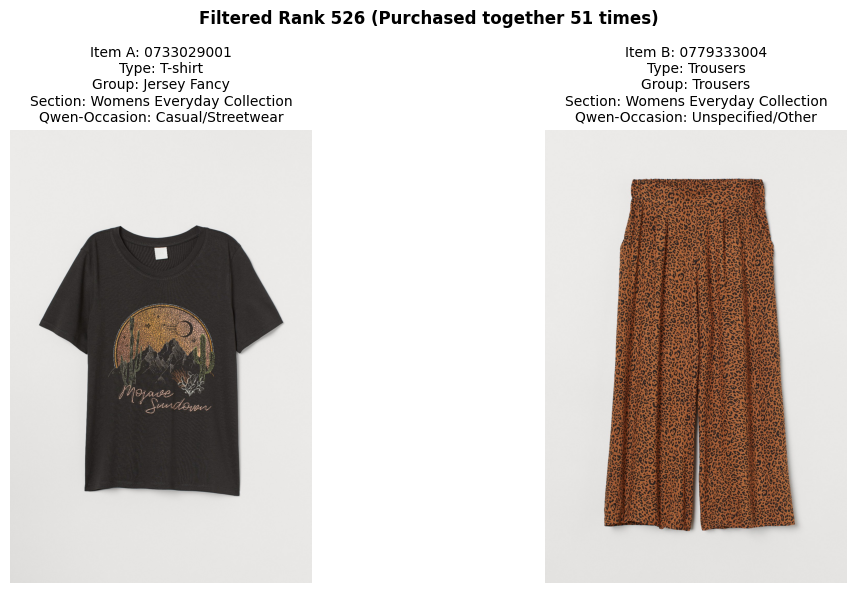

In [316]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

def get_image_path(article_id):
    article_id_str = str(article_id).zfill(10)
    return os.path.join("images", article_id_str[:3], f"{article_id_str}.jpg")

# ==========================================
check = "random" # Thay bằng số nguyên (ví dụ: 10, 50) để soi Rank cụ thể
# ==========================================

total_filtered = len(df_filtered)
if check == "random":
    idx = random.randint(0, min(1000, total_filtered - 1)) # Chỉ soi random trong Top 1000 đồ xịn nhất
else:
    idx = check

row = df_filtered.iloc[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, prefix in enumerate(['A', 'B']):
    item_id = row[f'Item_{prefix}']
    img_path = get_image_path(item_id)
    
    if os.path.exists(img_path):
        axes[i].imshow(Image.open(img_path))
    else:
        axes[i].text(0.5, 0.5, 'Image Not Found', ha='center')
        
    # In ra toàn bộ metadata hữu ích để cậu đánh giá
    info = (f"Item {prefix}: {item_id}\n"
            f"Type: {row[f'product_type_name_{prefix}']}\n"
            f"Group: {row[f'garment_group_name_{prefix}']}\n"
            f"Section: {row[f'section_name_{prefix}']}\n"
            f"Qwen-Occasion: {row[f'occasion_{prefix}']}")
    axes[i].set_title(info, fontsize=10)
    axes[i].axis('off')

plt.suptitle(f"Filtered Rank {idx + 1} (Purchased together {row['Count']} times)", fontweight='bold')
plt.tight_layout()
plt.show()